In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/Loan_default.csv")

In [9]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("\nCategorical Columns:", categorical_cols)

Numerical Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']

Categorical Columns: ['LoanID', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner']


In [10]:
df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,255347.0,43.498306,14.990258,18.0,31.00,43.00,56.00,69.0
Income,255347.0,82499.304597,38963.013729,15000.0,48825.50,82466.00,116219.00,149999.0
LoanAmount,255347.0,127578.865512,70840.706142,5000.0,66156.00,127556.00,188985.00,249999.0
CreditScore,255347.0,574.264346,158.903867,300.0,437.00,574.00,712.00,849.0
MonthsEmployed,255347.0,59.541976,34.643376,0.0,30.00,60.00,90.00,119.0
NumCreditLines,255347.0,2.501036,1.117018,1.0,2.00,2.00,3.00,4.0
InterestRate,255347.0,13.492773,6.636443,2.0,7.77,13.46,19.25,25.0
LoanTerm,255347.0,36.025894,16.969330,12.0,24.00,36.00,48.00,60.0
DTIRatio,255347.0,0.500212,0.230917,0.1,0.30,0.50,0.70,0.9
Default,255347.0,0.116128,0.320379,0.0,0.00,0.00,0.00,1.0


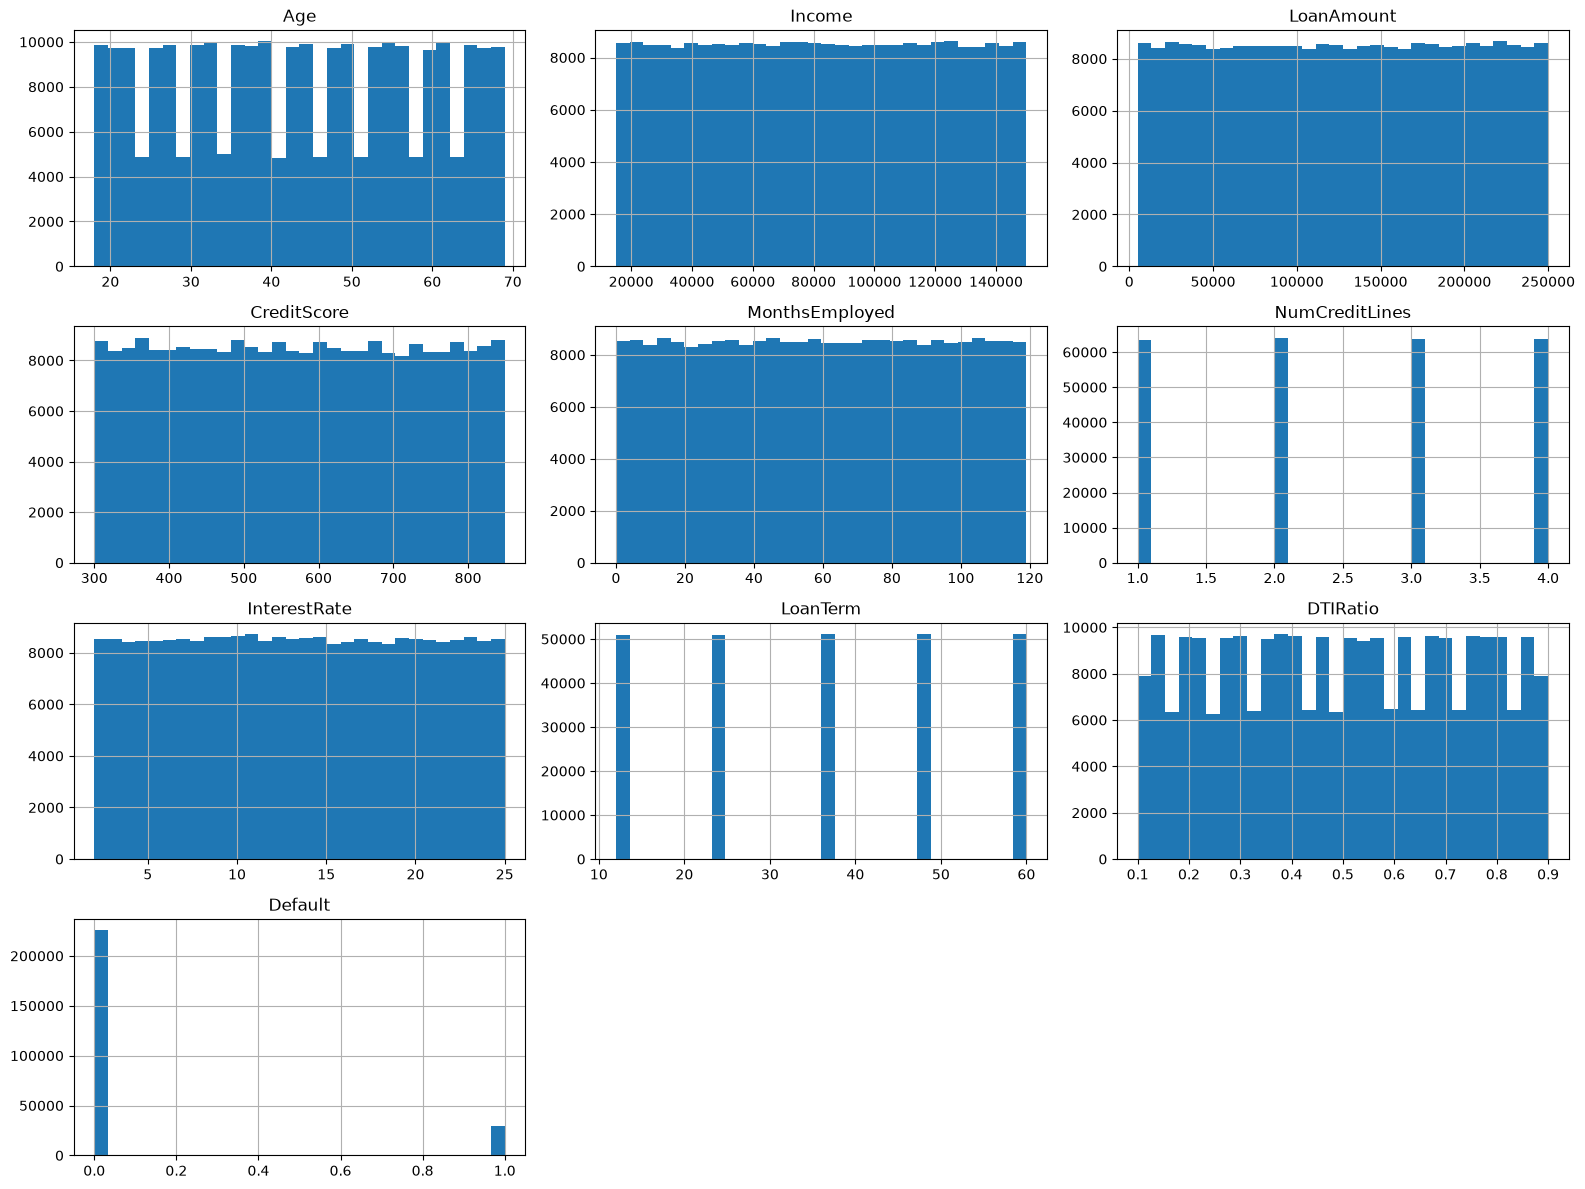

In [11]:
df[numerical_cols].hist(figsize=(16,12), bins=30)

plt.tight_layout()
plt.show()

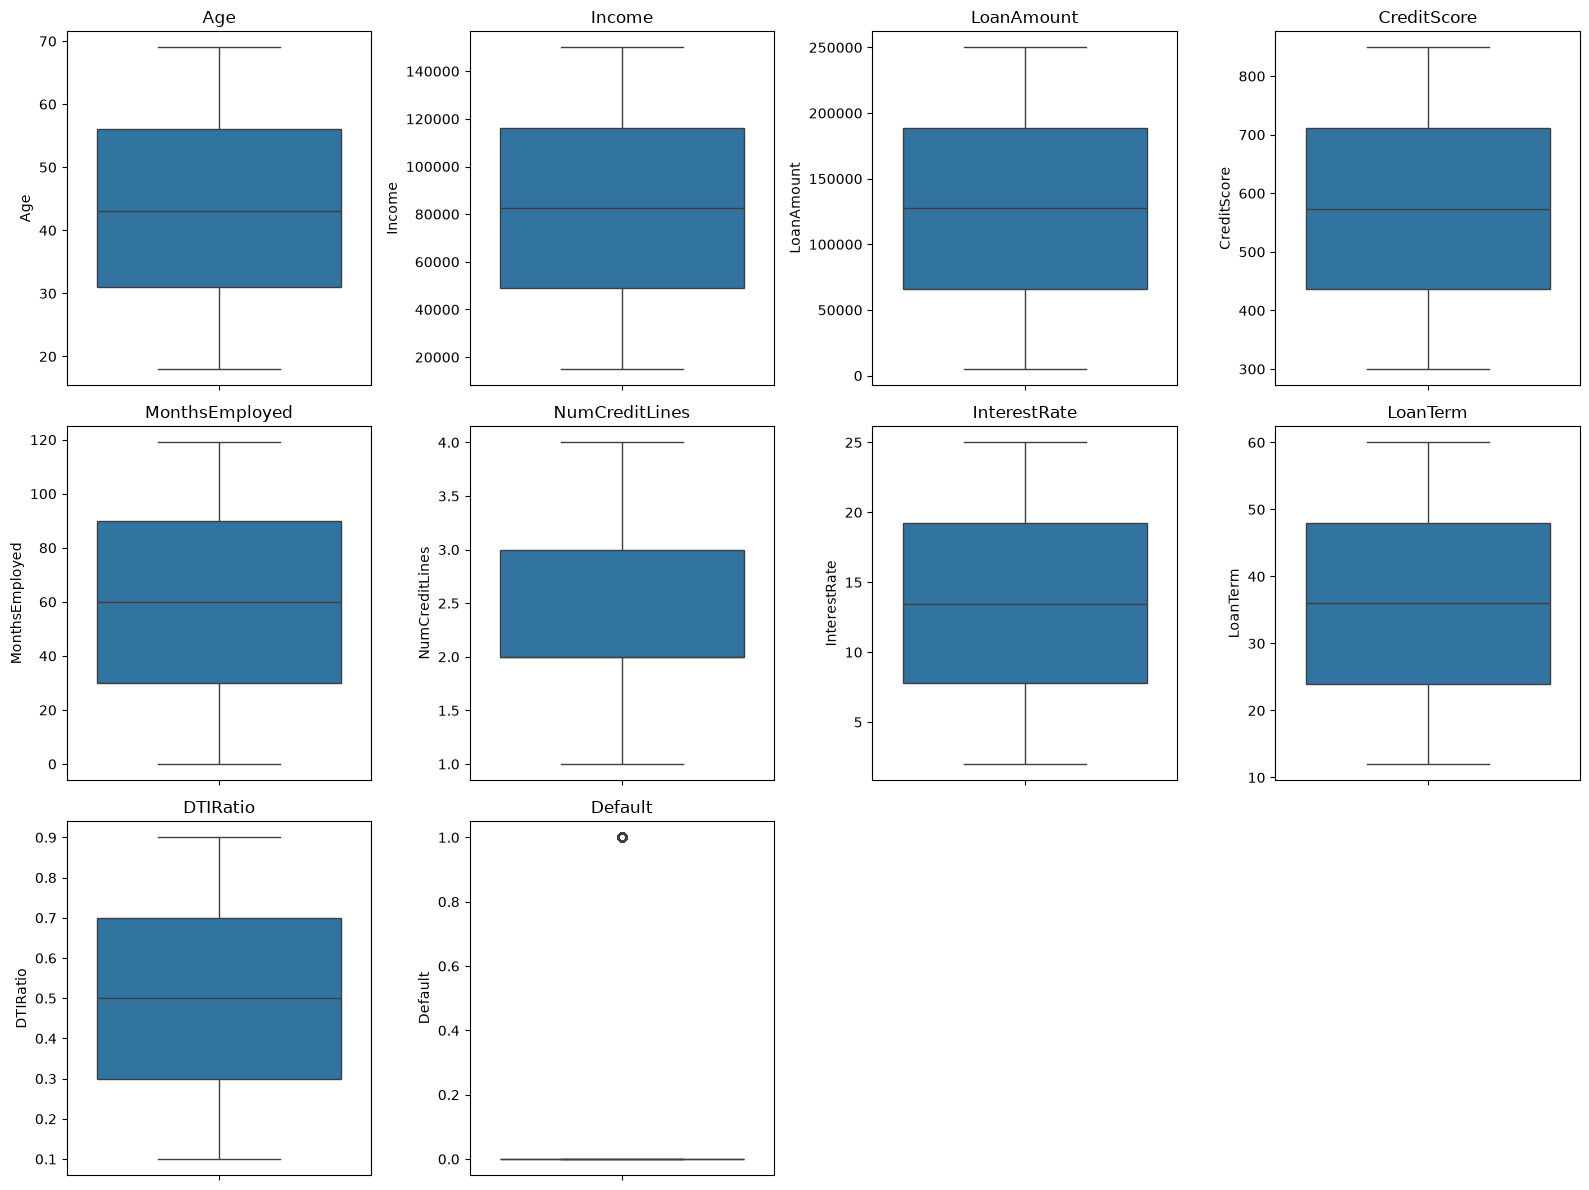

In [12]:
plt.figure(figsize=(16,12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3,4,i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [13]:
for col in categorical_cols:
    if col != "LoanID":
        print(f"\n{col}")
        print(pd.crosstab(df[col], df["Default"], normalize="index"))


Education
Default             0         1
Education                      
Bachelor's   0.878989  0.121011
High School  0.871211  0.128789
Master's     0.891283  0.108717
PhD          0.894140  0.105860

EmploymentType
Default                0         1
EmploymentType                    
Full-time       0.905366  0.094634
Part-time       0.880348  0.119652
Self-employed   0.885380  0.114620
Unemployed      0.864471  0.135529

MaritalStatus
Default               0         1
MaritalStatus                    
Divorced       0.874672  0.125328
Married        0.896028  0.103972
Single         0.880876  0.119124

HasMortgage
Default             0         1
HasMortgage                    
No           0.876549  0.123451
Yes          0.891194  0.108806

HasDependents
Default               0         1
HasDependents                    
No             0.872756  0.127244
Yes            0.894976  0.105024

LoanPurpose
Default             0         1
LoanPurpose                    
Auto         0.88

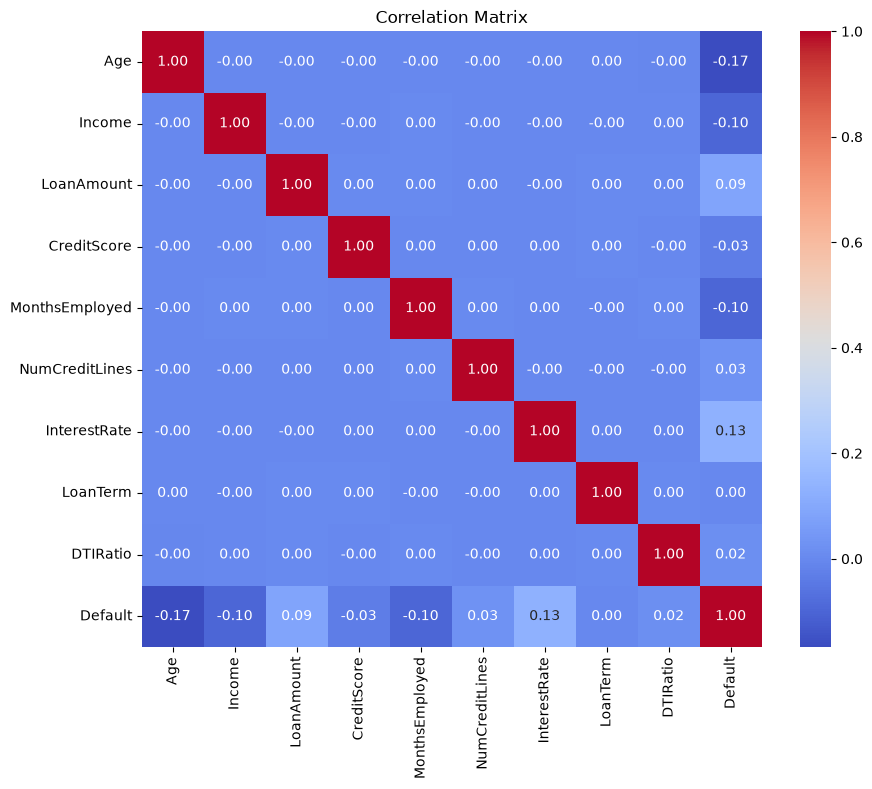

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(df[numerical_cols].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

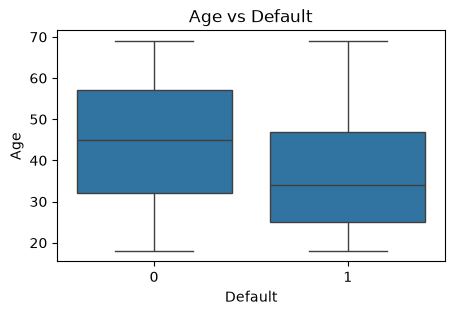

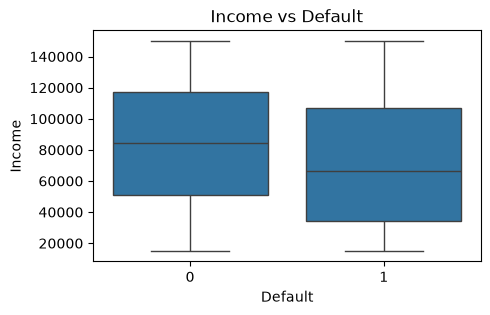

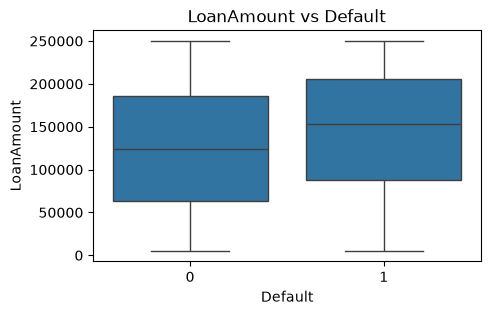

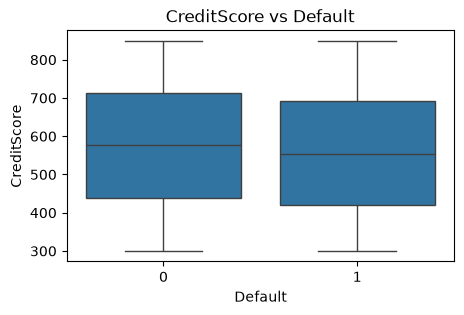

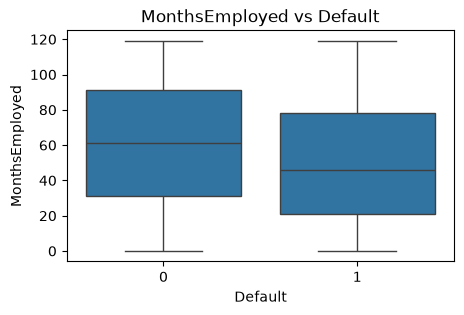

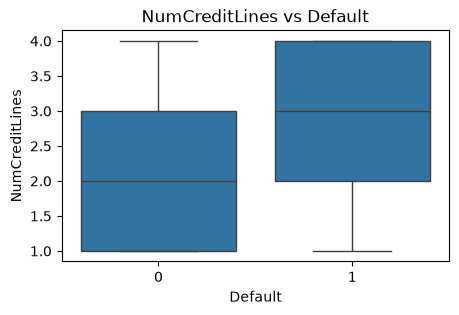

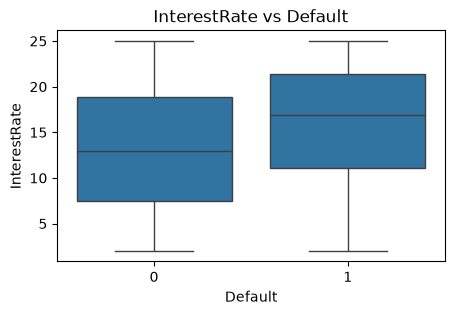

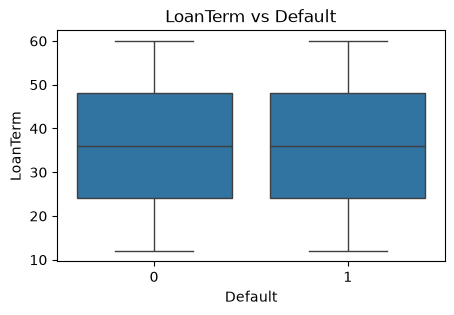

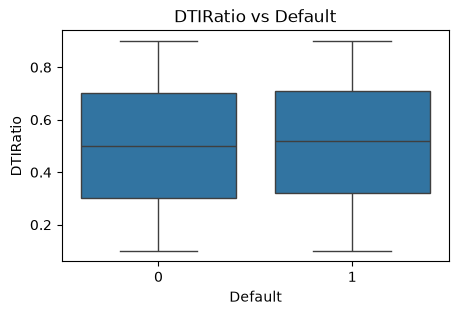

In [15]:
for col in numerical_cols:
    if col != "Default":
        plt.figure(figsize=(5,3))
        sns.boxplot(x="Default", y=col, data=df)
        plt.title(f"{col} vs Default")
        plt.show()

# Key Findings

- Summary of numerical variable distributions.
- Variables with significant outliers.
- Variables showing differences across default groups.
- Strong correlations (if any).
- Categorical variables associated with default.